# Lesson 8: Categorical Data: Chi-Square, Fisher, and McNemar

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Distinguish goodness-of-fit, independence, and paired categorical tests
2. Check expected counts and use exact methods for sparse 2x2 tables
3. Compute Cramér's V, odds ratios, and standardized residuals
4. Report counts, percentages, uncertainty, and practical meaning


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 8.1 Independence in a contingency table

For cell $(i,j)$, independence implies
$$E_{ij}=\frac{(\text{row total}_i)(\text{column total}_j)}{N}.$$
The Pearson statistic $\chi^2=\sum (O-E)^2/E$ aggregates discrepancies. Inspect expected counts and
residuals; a small p-value alone does not identify the important cells.


In [2]:
anes = pd.read_csv(DATA_DIR / "anes96_clean.csv")
table = pd.crosstab(anes["party_group"], anes["expected_vote"])
observed = table.to_numpy()
chi2, p, dof, expected = stats.chi2_contingency(observed, correction=False)
n = observed.sum()
cramer_v = np.sqrt(chi2/(n*(min(observed.shape)-1)))
residuals = (observed-expected)/np.sqrt(expected)
display(table)
print(f"chi-square({dof})={chi2:.3f}, p={p:.4g}, Cramer's V={cramer_v:.3f}")
display(pd.DataFrame(expected, index=table.index, columns=table.columns).round(2))
display(pd.DataFrame(residuals, index=table.index, columns=table.columns).round(2))


expected_vote,Clinton,Dole
party_group,,
Democrat,467,21
Independent,26,11
Republican,58,361


chi-square(2)=623.842, p=3.424e-136, Cramer's V=0.813


expected_vote,Clinton,Dole
party_group,,
Democrat,284.84,203.16
Independent,21.60,15.40
Republican,244.56,174.44


expected_vote,Clinton,Dole
party_group,,
Democrat,10.79,-12.78
Independent,0.95,-1.12
Republican,-11.93,14.13


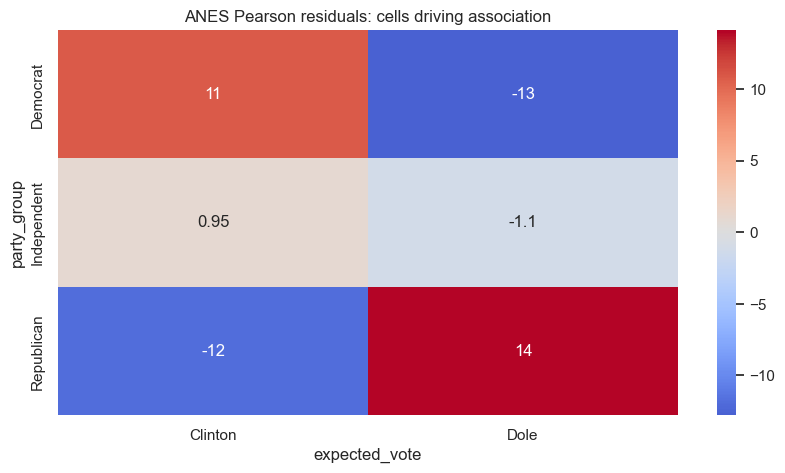

In [3]:
fig, ax = plt.subplots()
sns.heatmap(pd.DataFrame(residuals, index=table.index, columns=table.columns),
            annot=True, center=0, cmap="coolwarm", ax=ax)
ax.set_title("ANES Pearson residuals: cells driving association")
plt.show()


## 8.2 Sparse 2x2 tables and effect measures

Fisher's exact test conditions on the margins and is valid with small counts. For a 2x2 table, report
an odds ratio and confidence interval. Relative risk is often easier to interpret in cohort or
randomized designs; odds ratios are natural in case-control studies and logistic regression.


In [4]:
spector = pd.read_csv(DATA_DIR / "spector_program.csv")
sparse_table = pd.crosstab(spector["program_group"], spector["grade_improved"])
sparse = sparse_table.to_numpy()
fisher = stats.fisher_exact(sparse, alternative="two-sided")
from statsmodels.stats.contingency_tables import Table2x2
t22 = Table2x2(sparse)
ci = t22.oddsratio_confint()
display(sparse_table)
pd.Series({"odds ratio": fisher.statistic, "exact p": fisher.pvalue,
           "OR CI low": ci[0], "OR CI high": ci[1]})


grade_improved,0,1
program_group,,
No PSI,15,3
PSI,6,8


odds ratio     6.6667
exact p        0.0265
OR CI low      1.3062
OR CI high    34.0270
dtype: float64

## Worked example and interpretation

### Reading a contingency table

The ANES table cross-classifies party identification and expected vote for 944 respondents. The chi-square independence test compares observed counts with counts calculated from the row and column totals under independence. It gives chi-square = 623.84 on 2 degrees of freedom and p about 3.4 × 10⁻¹³⁶; Cramér's V = 0.813 describes a strong association in this table. The residual heatmap identifies influential cells: Democrat/Clinton is above its independence expectation and Republican/Dole is far above its expectation. Neither a large statistic nor a residual shows that party identification *causes* a vote choice.

### Small tables and dependence

The Spector 2×2 table contains 15/3 unimproved/improved students in the No PSI group and 6/8 in PSI. Fisher's exact test gives p = 0.0265 and an odds ratio of 6.67 for improvement under the table's orientation. The displayed 95% odds-ratio interval, 1.31 to 34.03, comes from a separate `Table2x2` calculation and is wide; do not describe it as an exact interval. Fisher applies to **independent** groups. If the same people are measured twice on a binary outcome, McNemar uses discordant pairs instead, as demonstrated with firms in Lesson 5.

## Practice and solution

**Practice.** Which test fits each case: (a) one die rolled 120 times; (b) device type versus conversion
in independent users; (c) the same users' subscription status before and after a campaign?

<details><summary>Solution</summary>

(a) Chi-square goodness-of-fit against the six expected probabilities. (b) Chi-square independence or
two-proportion test; use Fisher exact if expected counts are sparse. (c) McNemar, because outcomes are
paired binary measurements.
</details>

## Key takeaways

- Select the categorical test from the sampling structure.
- Check expected—not observed—counts for chi-square adequacy.
- Report interpretable risks or odds with intervals, not only an association p-value.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
